# Black-hole binary formation channels with gaussian mixtures

In [14]:
import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from astroML import stats as astroMLstats
import numpy as np
from matplotlib import pyplot as plt
import math

from sklearn.mixture import GaussianMixture

In [7]:
data=np.load('formationchannels.npy')

In [8]:
print(data, data.shape)

[[17.12172682]
 [ 5.94121793]
 [ 6.35914124]
 ...
 [34.34170191]
 [30.27018478]
 [25.93264098]] (2950, 1)


(array([0.00063165, 0.        , 0.00063165, 0.00063165, 0.00063165,
        0.        , 0.00126329, 0.00189494, 0.00126329, 0.00063165,
        0.00252658, 0.00063165, 0.00189494, 0.00442152, 0.00378987,
        0.0069481 , 0.00252658, 0.0069481 , 0.00568481, 0.00947468,
        0.00821139, 0.00568481, 0.0069481 , 0.01200126, 0.01200126,
        0.0069481 , 0.01010633, 0.01073797, 0.01200126, 0.00757974,
        0.00884304, 0.00884304, 0.00568481, 0.00947468, 0.00821139,
        0.00252658, 0.00757974, 0.00631645, 0.00189494, 0.00315823,
        0.00505316, 0.00884304, 0.01452784, 0.02526582, 0.04547847,
        0.07390251, 0.09158858, 0.08148226, 0.06569112, 0.03221392,
        0.02400253, 0.01642278, 0.03031898, 0.0277924 , 0.02968733,
        0.02968733, 0.03221392, 0.04611011, 0.03726708, 0.05053163,
        0.04358353, 0.04737341, 0.04926834, 0.05368986, 0.05179492,
        0.0555848 , 0.0543215 , 0.05305821, 0.05053163, 0.04484682,
        0.05495315, 0.03663543, 0.03600379, 0.04

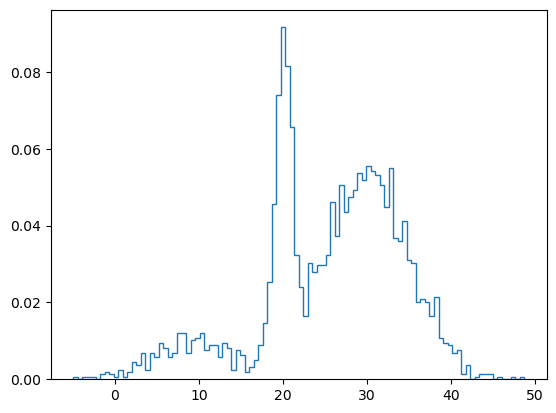

In [13]:
plt.hist(data, bins=100, histtype='step', density=True)

In [46]:
aic=[]
for N in range (1,11):
    GaussMix=GaussianMixture(n_components=N).fit(data)
    aic.append(GaussMix.aic(data))

Text(0, 0.5, 'AIC')

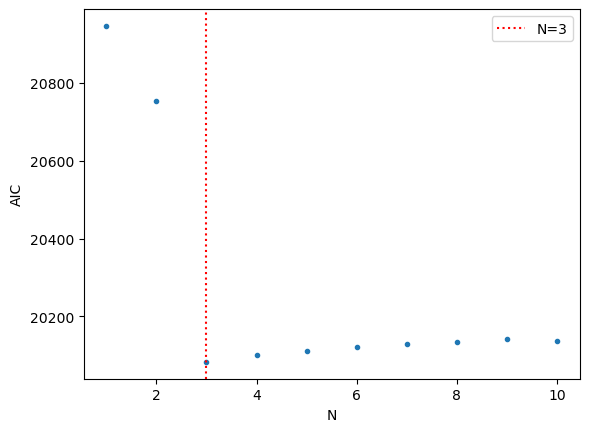

In [130]:
N=np.linspace(1,10,10)
plt.plot(N,aic, '.')
plt.axvline(3,c='red', ls='dotted', label='N=3')
plt.legend()
plt.xlabel('N')
plt.ylabel('AIC')

In [125]:
GaussMix=GaussianMixture(n_components=3).fit(data)

In [126]:
mu=[]
sigma=[]
weight=[]
for n in range (0,3):
    mu.append(GaussMix.means_[n][0])
    sigma.append((GaussMix.covariances_[n][0])**(0.5))
    weight.append(GaussMix.weights_[n])

In [127]:
G1 = norm(mu[0], sigma[0][0])
G2 = norm(mu[1], sigma[1][0])
G3 = norm(mu[2], sigma[2][0])

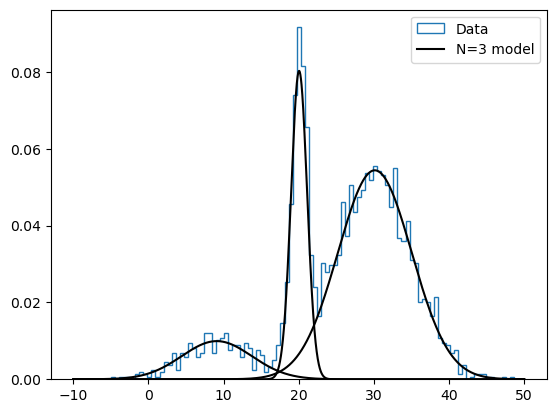

In [128]:
plt.hist(data, bins=100, histtype='step', density=True, label='Data')
plt.plot(xplot, weight[0]* G1.pdf(xplot), color='black', label='N=3 model')
plt.plot(xplot, weight[1]* G2.pdf(xplot), color='black')
plt.plot(xplot, weight[2]* G3.pdf(xplot), color='black')
plt.legend()